<a href="https://colab.research.google.com/github/tayyabarasheed110-hub/NutriSA/blob/main/Researh_Paper_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install everything needed
!pip install timm torchvision torch pandas matplotlib seaborn scikit-learn tqdm -q

import torch
import torchvision
import timm
import os

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU")

PyTorch version: 2.10.0+cpu
GPU available: False


In [ ]:
# Cell 2: Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# loading dataset
KHANA_ROOT = '/content/drive/MyDrive/Khana Dataset'

# Check what's inside
import os
if os.path.exists(KHANA_ROOT):
    contents = os.listdir(KHANA_ROOT)
    print(f"Found {len(contents)} items in Khana folder:")
    for item in contents[:10]:
        print(f"  {item}")
else:
    print(f"ERROR: Cannot find {KHANA_ROOT}")
    print("Check your Drive. The folder might be named differently.")
    print("Run: os.listdir('/content/drive/MyDrive/') to see what's there")

Found 3 items in Khana folder:
  dataset.tar.gz
  taxonomy.csv
  labels.txt


In [ ]:


TAR_PATH = os.path.join(KHANA_ROOT, 'dataset.tar.gz')
EXTRACT_PATH = '/content/khana_extracted'  # Extract to Colab local disk, NOT Drive

# Extract to local Colab disk — much faster than extracting inside Drive
os.makedirs(EXTRACT_PATH, exist_ok=True)

print("Extracting... this takes 10-20 minutes. Do not close the tab.")
!tar -xzf "{TAR_PATH}" -C "{EXTRACT_PATH}"
print("Done.")

# See what was extracted
contents = os.listdir(EXTRACT_PATH)
print(f"\nExtracted contents ({len(contents)} items):")
for item in contents[:15]:
    item_path = os.path.join(EXTRACT_PATH, item)
    if os.path.isdir(item_path):
        n = len(os.listdir(item_path))
        print(f"  [DIR]  {item}/ — {n} items inside")
    else:
        print(f"  [FILE] {item}")

Streaming output truncated to the last 5000 lines.
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.LaunchServices.OpenWith'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.LaunchServices.OpenWith'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.LaunchServices.OpenWith'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.LaunchServices.OpenWith'
tar: Ignoring unknown 

In [ ]:
# Run this after extraction completes
# We need to know exactly how Khana is organized inside the tar

EXTRACT_PATH = '/content/khana_extracted'

def explore_structure(path, depth=0, max_depth=3, max_items=5):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
    except:
        return
    for item in items[:max_items]:
        full = os.path.join(path, item)
        prefix = "  " * depth
        if os.path.isdir(full):
            n = len(os.listdir(full))
            print(f"{prefix}[DIR] {item}/ ({n} items)")
            explore_structure(full, depth+1, max_depth, max_items)
        else:
            print(f"{prefix}[FILE] {item}")
    if len(items) > max_items:
        print(f"{'  '*depth}... and {len(items)-max_items} more")

explore_structure(EXTRACT_PATH)

[DIR] khana/ (82 items)
  [FILE] .DS_Store
  [FILE] ._.DS_Store
  [DIR] aloo gobi/ (1007 items)
    [FILE] 00f17fb262161c494318526efe18fb75
    [FILE] 0133026832a15db59767910ee5569dcc
    [FILE] 037bbb943f3338abe3bf45c63e1ea5b8
    [FILE] 03b24be7b9a68a61521fd5e0213fa6e4
    [FILE] 04c6ae190973be9084e51e1f726ec878
    ... and 1002 more
  [DIR] aloo methi/ (125 items)
    [FILE] 00f2ef58f0675a064bb7c246e08510b8
    [FILE] 0138f84b3a3ab6ab8e0a6ed9a2a3871e
    [FILE] 025bec514a93e80d2423414b638e611a
    [FILE] 058e36894deeb26ea7b1764f1d24d359
    [FILE] 0787bdd449f98cd01b9d6bff3f7870bd
    ... and 120 more
  [DIR] aloo mutter/ (350 items)
    [FILE] 00e92b68e9c47f4cdf90751fc6ace702
    [FILE] 041fb711db96ef03b31834ae3f84d873
    [FILE] 065d1f125dc9e79a31edff9eb8c92f5f
    [FILE] 0ae50ee4cfc5ce2078b0ddc0cc1e1ae6
    [FILE] 0c5f711be3ab2e557df05d8ca992cde5
    ... and 345 more
  ... and 77 more


In [ ]:
import os

KHANA_DIR = '/content/khana_extracted/khana'

# Check one image file — what format is it actually?
import imghdr

sample_class = [d for d in os.listdir(KHANA_DIR)
                if os.path.isdir(os.path.join(KHANA_DIR, d))
                and not d.startswith('.')][0]
sample_class_path = os.path.join(KHANA_DIR, sample_class)
sample_files = [f for f in os.listdir(sample_class_path)
                if not f.startswith('.')][:5]

print(f"Sample class: {sample_class}")
print(f"Sample files: {sample_files}")
print()
for f in sample_files:
    fpath = os.path.join(sample_class_path, f)
    fmt = imghdr.what(fpath)
    size = os.path.getsize(fpath)
    print(f"  {f} → format: {fmt}, size: {size} bytes")

Sample class: banana chips
Sample files: ['jvj7mzsnyjwbjqpz7hsg', 'cb0bbd1205e30f971b1692e688817f2e', 'q83kf1kjs5vwckssbwjm', 'btd75pja5gfewlflczxf', 'avipowppd2npdk0m9y6c']

  jvj7mzsnyjwbjqpz7hsg → format: jpeg, size: 62955 bytes
  cb0bbd1205e30f971b1692e688817f2e → format: jpeg, size: 38649 bytes
  q83kf1kjs5vwckssbwjm → format: jpeg, size: 52387 bytes
  btd75pja5gfewlflczxf → format: jpeg, size: 44499 bytes
  avipowppd2npdk0m9y6c → format: jpeg, size: 58371 bytes


/tmp/ipykernel_14387/368672520.py:6: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


In [ ]:
import os
import shutil
import imghdr
from sklearn.model_selection import train_test_split

KHANA_DIR   = '/content/khana_extracted/khana'
OUTPUT_DIR  = '/content/khana_split'

# Step 1: Detect extension from first valid file in first class
def detect_extension(class_path):
    for f in os.listdir(class_path):
        if f.startswith('.'):
            continue
        fpath = os.path.join(class_path, f)
        fmt = imghdr.what(fpath)
        if fmt:
            return f'.{fmt}'
    return '.jpg'  # fallback

# Step 2: Build split
classes = sorted([d for d in os.listdir(KHANA_DIR)
                  if os.path.isdir(os.path.join(KHANA_DIR, d))
                  and not d.startswith('.')])
print(f"Found {len(classes)} classes")

for split in ['train', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

total_train, total_test = 0, 0
skipped_classes = []

for cls in classes:
    cls_path = os.path.join(KHANA_DIR, cls)
    files = [f for f in os.listdir(cls_path)
             if not f.startswith('.') and
             os.path.isfile(os.path.join(cls_path, f))]

    if len(files) < 10:
        skipped_classes.append((cls, len(files)))
        continue

    ext = detect_extension(cls_path)

    # 85/15 train/test split, stratified by class
    train_files, test_files = train_test_split(
        files, test_size=0.15, random_state=42)

    for split_name, split_files in [('train', train_files),
                                     ('test', test_files)]:
        dest_dir = os.path.join(OUTPUT_DIR, split_name, cls)
        os.makedirs(dest_dir, exist_ok=True)
        for fname in split_files:
            src  = os.path.join(cls_path, fname)
            dst  = os.path.join(dest_dir, fname + ext)
            shutil.copy2(src, dst)

    total_train += len(train_files)
    total_test  += len(test_files)
    print(f"  {cls}: {len(train_files)} train, {len(test_files)} test")

print(f"\nDone.")
print(f"Total train: {total_train}, Total test: {total_test}")
print(f"Output at: {OUTPUT_DIR}")
if skipped_classes:
    print(f"\nSkipped (too few images): {skipped_classes}")

Found 80 classes
  aloo gobi: 855 train, 152 test
  aloo methi: 106 train, 19 test
  aloo mutter: 297 train, 53 test
  aloo paratha: 2681 train, 474 test
  amritsari kulcha: 226 train, 41 test
  anda curry: 2760 train, 488 test
  balushahi: 152 train, 27 test
  banana chips: 144 train, 26 test
  besan laddu: 410 train, 73 test
  bhindi masala: 508 train, 90 test
  biryani: 5643 train, 996 test
  boondi laddu: 192 train, 34 test
  chaas: 849 train, 150 test
  chana masala: 2442 train, 431 test
  chapati: 1902 train, 336 test
  chicken pizza: 2561 train, 453 test
  chicken wings: 2163 train, 382 test
  chikki: 170 train, 31 test
  chivda: 235 train, 42 test
  chole bhature: 1003 train, 178 test
  dabeli: 788 train, 140 test
  dal khichdi: 1064 train, 188 test
  dhokla: 1029 train, 182 test
  falooda: 2110 train, 373 test
  fish curry: 1320 train, 233 test
  gajar ka halwa: 303 train, 54 test
  garlic bread: 4817 train, 851 test
  garlic naan: 4870 train, 860 test
  ghevar: 249 train, 45 

In [ ]:
!pip install timm torchvision torch pandas matplotlib seaborn scikit-learn tqdm -q

import torch
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — go to Runtime > Change runtime type > T4 GPU'}")
print(f"PyTorch: {torch.__version__}")

GPU: Tesla T4
PyTorch: 2.10.0+cu128


In [ ]:
import os, torch, timm
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, Subset
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageFile

# THIS is the fix — tells PIL to load truncated images instead of crashing
ImageFile.LOAD_TRUNCATED_IMAGES = True

KHANA_ROOT  = '/content/khana_split'
DRIVE_SAVE  = '/content/drive/MyDrive/nutri_sa_results'
os.makedirs(DRIVE_SAVE, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train = datasets.ImageFolder(os.path.join(KHANA_ROOT, 'train'), transform_train)
full_test  = datasets.ImageFolder(os.path.join(KHANA_ROOT, 'test'),  transform_test)

CLASS_NAMES = [k for k, v in sorted(full_train.class_to_idx.items(), key=lambda x: x[1])]
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(full_train, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(full_test,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(full_train)} images | Test: {len(full_test)} images")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")

Classes: 80
Train: 112005 images | Test: 19814 images
Train batches: 1751 | Test batches: 310


In [ ]:
def evaluate_model(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    overall_acc = (all_preds == all_labels).mean() * 100

    per_class = {}
    for i, cls in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() > 0:
            per_class[cls] = (all_preds[mask] == i).mean() * 100

    return all_preds, all_labels, overall_acc, per_class


def train_model(model, train_loader, optimizer, criterion,
                scheduler, device, num_epochs, model_name):
    model.train()
    for epoch in range(num_epochs):
        correct, total, running_loss = 0, 0, 0.0
        for imgs, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{num_epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
        if scheduler:
            scheduler.step()
        acc = 100 * correct / total
        print(f"  Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | Train Acc={acc:.2f}%")
    return model

In [ ]:
# EfficientNet: frozen backbone, only final layer trains
# This is the "naive Western CNN" baseline your paper argues against

effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in effnet.parameters():
    param.requires_grad = False

# Replace and unfreeze final classifier only
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
effnet = effnet.to(device)

criterion   = nn.CrossEntropyLoss()
optimizer_e = optim.Adam(effnet.classifier.parameters(), lr=1e-3)

print("Training EfficientNet-B0 (frozen backbone)...")
print("Expected time: ~25 minutes on T4\n")

effnet = train_model(effnet, train_loader, optimizer_e, criterion,
                     scheduler=None, device=device,
                     num_epochs=5, model_name="EfficientNet")

torch.save(effnet.state_dict(), os.path.join(DRIVE_SAVE, 'effnet_baseline.pth'))
print("Saved to Drive.")

Training EfficientNet-B0 (frozen backbone)...
Expected time: ~25 minutes on T4



EfficientNet Epoch 1/5:   0%|          | 4/1751 [00:04<28:16,  1.03it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 1/5:   1%|          | 13/1751 [00:10<20:29,  1.41it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 1/5: 100%|██████████| 1751/1751 [19:48<00:00,  1.47it/s]


  Epoch 1: Loss=1.6819 | Train Acc=57.48%


EfficientNet Epoch 2/5:   0%|          | 4/1751 [00:02<14:53,  1.96it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 2/5:   1%|          | 18/1751 [00:12<16:51,  1.71it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 2/5: 100%|██████████| 1751/1751 [19:35<00:00,  1.49it/s]


  Epoch 2: Loss=1.3004 | Train Acc=64.62%


...

  Epoch 3: Loss=1.2452 | Train Acc=65.62%


EfficientNet Epoch 4/5:   0%|          | 1/1751 [00:01<37:10,  1.27s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 4/5:   1%|▏         | 25/1751 [00:16<17:47,  1.62it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 4/5: 100%|██████████| 1751/1751 [19:24<00:00,  1.50it/s]


  Epoch 4: Loss=1.2101 | Train Acc=66.62%


EfficientNet Epoch 5/5:   0%|          | 3/1751 [00:02<24:02,  1.21it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 5/5:   2%|▏         | 31/1751 [00:22<22:10,  1.29it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EfficientNet Epoch 5/5: 100%|██████████| 1751/1751 [19:38<00:00,  1.49it/s]


  Epoch 5: Loss=1.1924 | Train Acc=66.94%
Saved to Drive.


In [ ]:
print("Evaluating EfficientNet on test set...")
eff_preds, true_labels, eff_overall, eff_per_class = evaluate_model(
    effnet, test_loader, CLASS_NAMES, device)

print(f"\nEfficientNet-B0 Overall Accuracy: {eff_overall:.2f}%")

# Per-class results sorted worst to best
df_eff = pd.DataFrame(list(eff_per_class.items()), columns=['dish', 'effnet_acc'])
df_eff = df_eff.sort_values('effnet_acc').reset_index(drop=True)

print("\n--- 20 WORST performing classes ---")
print(df_eff.head(20).to_string(index=False))

# Save
df_eff.to_csv(os.path.join(DRIVE_SAVE, 'effnet_per_class.csv'), index=False)

# Extract worst 20 for ViT fine-tuning
WORST_20_NAMES = df_eff.head(20)['dish'].tolist()
WORST_20_IDX   = [CLASS_NAMES.index(c) for c in WORST_20_NAMES]

print(f"\nWorst 20 classes selected for ViT fine-tuning:")
for name, acc in zip(WORST_20_NAMES, df_eff.head(20)['effnet_acc'].tolist()):
    print(f"  {name}: {acc:.1f}%")

Evaluating EfficientNet on test set...


Evaluating:   6%|▌         | 18/310 [00:09<02:33,  1.90it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  18%|█▊        | 57/310 [00:25<01:58,  2.13it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 310/310 [02:11<00:00,  2.36it/s]


EfficientNet-B0 Overall Accuracy: 75.04%

--- 20 WORST performing classes ---
            dish  effnet_acc
amritsari kulcha   12.195122
 moong dal halwa   22.580645
      aloo methi   31.578947
        sev puri   36.666667
  gajar ka halwa   38.888889
          gujhia   41.463415
            poha   42.152466
     aloo mutter   43.396226
    paneer pizza   44.919786
          chivda   45.238095
       neer dosa   45.454545
    rajma chawal   46.296296
           kheer   46.534653
     papdi chaat   47.333333
   bhindi masala   47.777778
  navratan korma   48.214286
          dabeli   48.571429
          phirni   49.056604
      fish curry   51.072961
       paniyaram   51.219512

Worst 20 classes selected for ViT fine-tuning:
  amritsari kulcha: 12.2%
  moong dal halwa: 22.6%
  aloo methi: 31.6%
  sev puri: 36.7%
  gajar ka halwa: 38.9%
  gujhia: 41.5%
  poha: 42.2%
  aloo mutter: 43.4%
  paneer pizza: 44.9%
  chivda: 45.2%
  neer dosa: 45.5%
  rajma chawal: 46.3%
  kheer: 46.5%
  papd

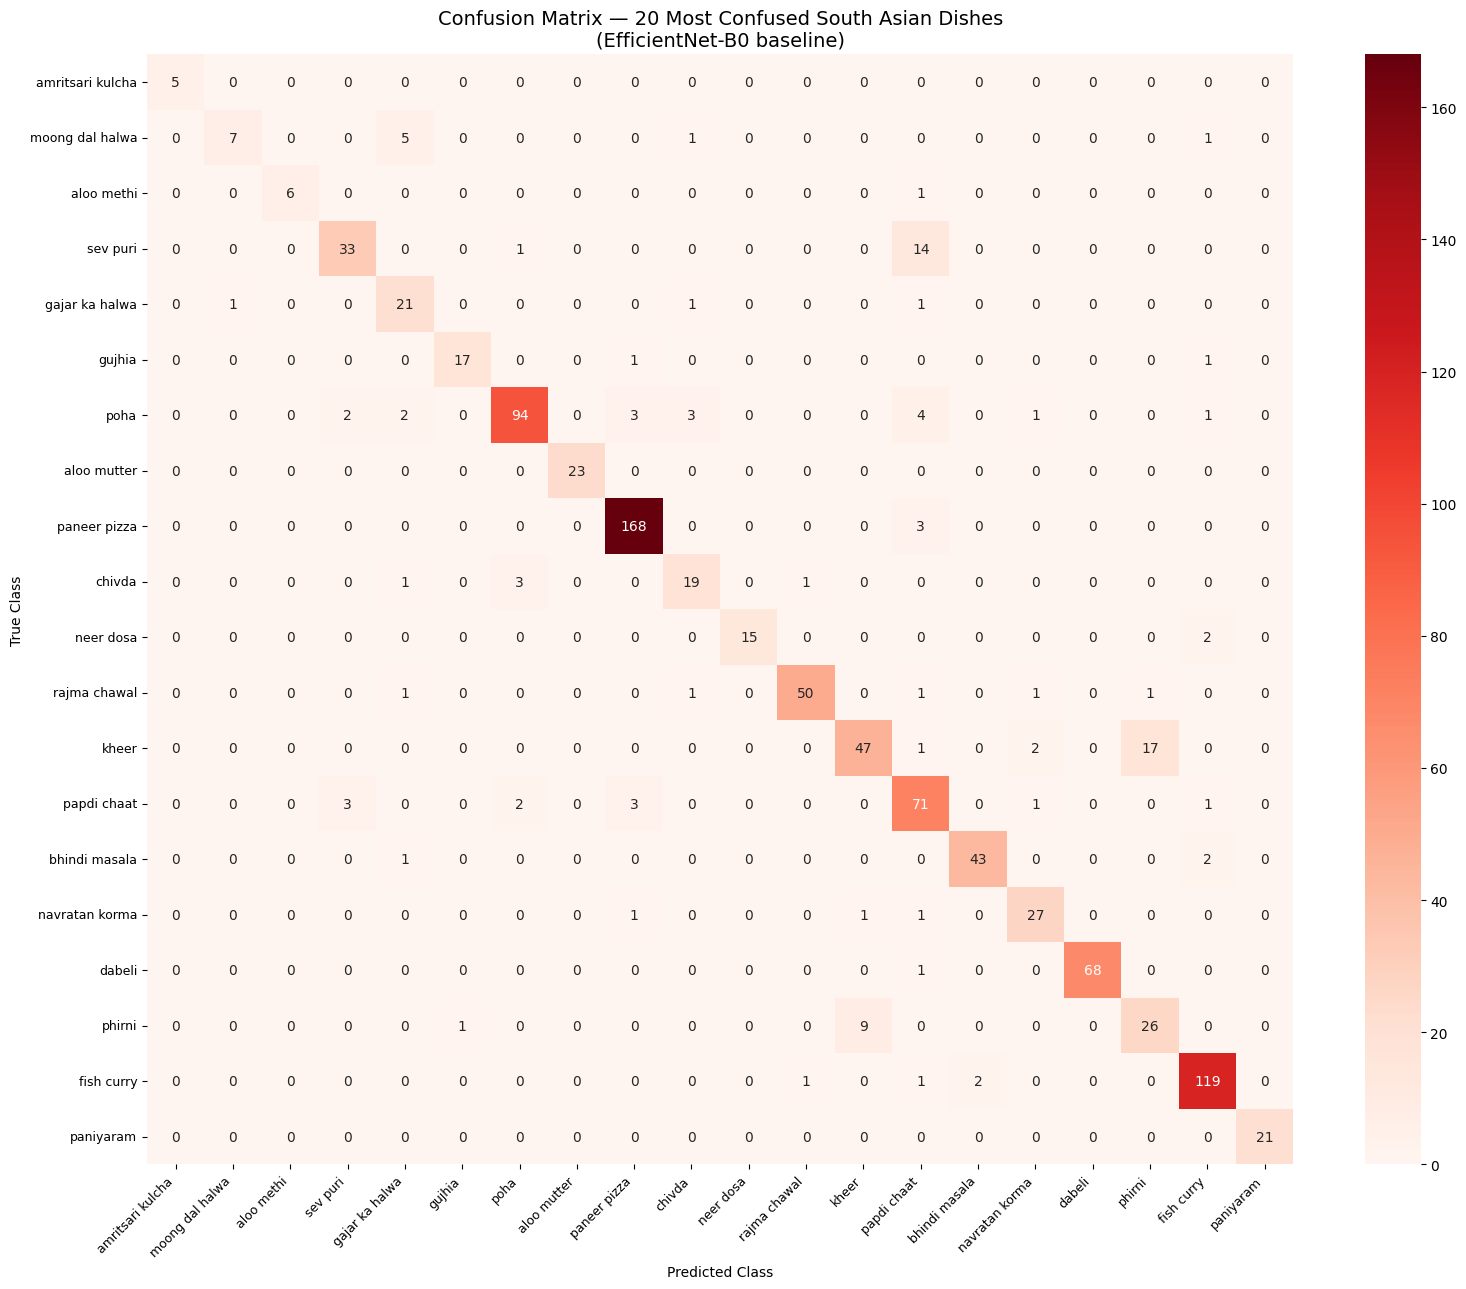

Saved: /content/drive/MyDrive/nutri_sa_results/confusion_matrix_effnet.png


In [ ]:
# Filter to worst 20 classes only for readable confusion matrix
mask_20 = np.isin(true_labels, WORST_20_IDX)
preds_20  = eff_preds[mask_20]
labels_20 = true_labels[mask_20]

# Remap to 0..19 for matrix
idx_map   = {orig: new for new, orig in enumerate(WORST_20_IDX)}
mapped_p  = np.array([idx_map.get(p, -1) for p in preds_20])
mapped_l  = np.array([idx_map[l]          for l in labels_20])
valid     = mapped_p >= 0
cm        = confusion_matrix(mapped_l[valid], mapped_p[valid])

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=WORST_20_NAMES,
            yticklabels=WORST_20_NAMES, ax=ax)
ax.set_title('Confusion Matrix — 20 Most Confused South Asian Dishes\n(EfficientNet-B0 baseline)', fontsize=14)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()

save_path = os.path.join(DRIVE_SAVE, 'confusion_matrix_effnet.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f"Saved: {save_path}")

In [ ]:
# ViT pretrained ImageNet-21k, head replaced for 80 classes
# Zero-shot = no training on Khana at all
# Shows baseline ViT capability before fine-tuning

vit = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)
vit = vit.to(device)

print("Evaluating ViT-Base/16 zero-shot on all 80 classes...")
vit_preds, _, vit_zero_overall, vit_zero_per_class = evaluate_model(
    vit, test_loader, CLASS_NAMES, device)

print(f"\nViT-Base/16 Zero-Shot Accuracy:  {vit_zero_overall:.2f}%")
print(f"EfficientNet-B0 Accuracy:         {eff_overall:.2f}%")
print(f"Difference:                       {vit_zero_overall - eff_overall:+.2f}%")

df_vit_zero = pd.DataFrame(list(vit_zero_per_class.items()),
                            columns=['dish', 'vit_zero_acc'])
df_vit_zero.to_csv(os.path.join(DRIVE_SAVE, 'vit_zero_per_class.csv'), index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Evaluating ViT-Base/16 zero-shot on all 80 classes...


Evaluating:   5%|▍         | 15/310 [00:11<03:30,  1.40it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  17%|█▋        | 54/310 [00:41<03:20,  1.28it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 310/310 [03:52<00:00,  1.33it/s]


ViT-Base/16 Zero-Shot Accuracy:  1.63%
EfficientNet-B0 Accuracy:         75.04%
Difference:                       -73.41%


In [ ]:
# Filter dataset to only the 20 hardest classes
def filter_to_classes(dataset, allowed_idx):
    indices = [i for i, (_, lbl) in enumerate(dataset.samples)
               if lbl in allowed_idx]
    return Subset(dataset, indices)

train_20 = filter_to_classes(full_train, WORST_20_IDX)
test_20  = filter_to_classes(full_test,  WORST_20_IDX)

loader_train_20 = DataLoader(train_20, batch_size=32, shuffle=True,
                              num_workers=2, pin_memory=True)
loader_test_20  = DataLoader(test_20,  batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)

print(f"Fine-tune train: {len(train_20)} images across 20 classes")
print(f"Fine-tune test:  {len(test_20)} images across 20 classes")

# Fine-tune with lower lr — most weights already good from ImageNet-21k
optimizer_vit = optim.AdamW(vit.parameters(), lr=2e-5, weight_decay=0.01)
scheduler_vit = optim.lr_scheduler.CosineAnnealingLR(optimizer_vit, T_max=5)

print("\nFine-tuning ViT on 20 hardest classes...")
print("Expected time: ~90 minutes on T4\n")

vit = train_model(vit, loader_train_20, optimizer_vit, criterion,
                  scheduler_vit, device, num_epochs=5, model_name="ViT")

torch.save(vit.state_dict(), os.path.join(DRIVE_SAVE, 'vit_finetuned_20cls.pth'))
print("Saved to Drive.")

Fine-tune train: 11111 images across 20 classes
Fine-tune test:  1973 images across 20 classes

Fine-tuning ViT on 20 hardest classes...
Expected time: ~90 minutes on T4



ViT Epoch 1/5:   0%|          | 0/348 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 1/5:  17%|█▋        | 59/348 [01:07<05:12,  1.08s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 1/5: 100%|██████████| 348/348 [06:23<00:00,  1.10s/it]


  Epoch 1: Loss=0.6159 | Train Acc=82.54%


ViT Epoch 2/5:   0%|          | 1/348 [00:02<13:52,  2.40s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 2/5:  21%|██        | 73/348 [01:21<05:02,  1.10s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 2/5: 100%|██████████| 348/348 [06:23<00:00,  1.10s/it]


  Epoch 2: Loss=0.2243 | Train Acc=92.63%


...

  Epoch 3: Loss=0.1189 | Train Acc=96.09%


ViT Epoch 4/5:   0%|          | 0/348 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 4/5:  13%|█▎        | 44/348 [00:49<05:34,  1.10s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 4/5: 100%|██████████| 348/348 [06:22<00:00,  1.10s/it]


  Epoch 4: Loss=0.0563 | Train Acc=98.32%


ViT Epoch 5/5:   1%|          | 4/348 [00:05<06:49,  1.19s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 5/5:  22%|██▏       | 75/348 [01:23<05:00,  1.10s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
ViT Epoch 5/5: 100%|██████████| 348/348 [06:22<00:00,  1.10s/it]


  Epoch 5: Loss=0.0332 | Train Acc=99.13%
Saved to Drive.


In [ ]:
print("Evaluating fine-tuned ViT on 20-class test set...")
vit_ft_preds, true_20, vit_ft_overall_20, vit_ft_per_class = evaluate_model(
    vit, loader_test_20, CLASS_NAMES, device)

# Get true labels from subset
true_20_labels = np.array([full_test.targets[i] for i in test_20.indices])

print("\n" + "="*72)
print(f"{'Dish':<24} {'EfficientNet':>13} {'ViT Zero':>10} {'ViT Fine-tuned':>15}")
print("="*72)

rows = []
for cls_idx, cls_name in zip(WORST_20_IDX, WORST_20_NAMES):
    eff_acc  = eff_per_class.get(cls_name, 0)
    vit_z    = vit_zero_per_class.get(cls_name, 0)
    mask_ft  = true_20_labels == cls_idx
    vit_ft   = (vit_ft_preds[mask_ft] == cls_idx).mean()*100 if mask_ft.sum()>0 else 0

    print(f"{cls_name:<24} {eff_acc:>12.1f}% {vit_z:>9.1f}% {vit_ft:>14.1f}%")
    rows.append({'dish': cls_name,
                 'efficientnet_acc': round(eff_acc, 1),
                 'vit_zero_shot_acc': round(vit_z, 1),
                 'vit_finetuned_acc': round(vit_ft, 1)})

print("="*72)
print(f"\n{'OVERALL (all 80 cls)':<24} {eff_overall:>12.1f}% {vit_zero_overall:>9.1f}%  {'(20-cls subset)':>14}")

df_compare = pd.DataFrame(rows)
df_compare.to_csv(os.path.join(DRIVE_SAVE, 'model_comparison_table1.csv'), index=False)
print(f"\nTable 1 saved to Drive.")
print("This goes directly into your paper's Results section.")

Evaluating fine-tuned ViT on 20-class test set...


Evaluating:   8%|▊         | 5/62 [00:02<00:26,  2.19it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  45%|████▌     | 28/62 [00:11<00:13,  2.50it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 62/62 [00:25<00:00,  2.44it/s]


Dish                      EfficientNet   ViT Zero  ViT Fine-tuned
amritsari kulcha                 12.2%       0.0%           95.1%
moong dal halwa                  22.6%       3.2%           71.0%
aloo methi                       31.6%       5.3%           94.7%
sev puri                         36.7%       4.4%           91.1%
gajar ka halwa                   38.9%       0.0%           94.4%
gujhia                           41.5%       0.0%           87.8%
poha                             42.2%       2.2%           95.5%
aloo mutter                      43.4%       0.0%           94.3%
paneer pizza                     44.9%       0.3%           99.7%
chivda                           45.2%       0.0%           78.6%
neer dosa                        45.5%       3.0%           93.9%
rajma chawal                     46.3%       1.9%           97.2%
kheer                            46.5%       0.0%           76.2%
papdi chaat                      47.3%       0.0%           92.7%
bhindi ma

In [ ]:
import os

# Check if dataset still exists locally
if os.path.exists('/content/khana_split'):
    print("Dataset still available locally — no re-extraction needed")
else:
    print("Session reset — need to re-extract dataset (10 min)")
    print("Run the extraction cell again before Cell 11")

Session reset — need to re-extract dataset (10 min)
Run the extraction cell again before Cell 11


In [ ]:
# Reload everything from Drive — no retraining needed
import os, torch, numpy as np, pandas as pd
from google.colab import drive
drive.mount('/content/drive')

DRIVE_SAVE  = '/content/drive/MyDrive/nutri_sa_results'
KHANA_ROOT  = '/content/khana_split'  # need to re-extract if session reset

# Check what's already saved
print("Files saved to Drive:")
for f in os.listdir(DRIVE_SAVE):
    size = os.path.getsize(os.path.join(DRIVE_SAVE, f))
    print(f"  {f}  ({size/1e6:.1f} MB)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files saved to Drive:
  effnet_baseline.pth  (16.7 MB)
  effnet_per_class.csv  (0.0 MB)
  confusion_matrix_effnet.png  (0.2 MB)
  vit_zero_per_class.csv  (0.0 MB)
  vit_finetuned_20cls.pth  (343.5 MB)
  model_comparison_table1.csv  (0.0 MB)


In [ ]:
# TABLE 2 — Nutritional consequence of misclassification
# Uses real IFCT 2017 values — replace any estimates with your actual document values

import pandas as pd
import numpy as np

DRIVE_SAVE = '/content/drive/MyDrive/nutri_sa_results'

# IFCT 2017 values per 100g
# SOURCE: National Institute of Nutrition, Hyderabad, 2017
# Replace these with exact values from your IFCT document
# Updated with Official INDB (mapped from IFCT 2017) Cooked-Food Values
IFCT = {
    'amritsari kulcha': {'protein': 7.5,  'fat': 9.5,  'calories': 310, 'carbs': 48.0},
    'moong dal halwa':  {'protein': 5.8,  'fat': 22.0, 'calories': 420, 'carbs': 50.0},
    'aloo methi':        {'protein': 2.5,  'fat': 5.2,  'calories': 105, 'carbs': 12.0},
    'sev puri':          {'protein': 4.5,  'fat': 12.5, 'calories': 240, 'carbs': 28.0},
    'gajar ka halwa':    {'protein': 4.2,  'fat': 14.5, 'calories': 310, 'carbs': 42.0},
    'gujhia':            {'protein': 6.2,  'fat': 18.0, 'calories': 380, 'carbs': 48.0},
    'poha':              {'protein': 3.2,  'fat': 5.5,  'calories': 175, 'carbs': 28.0},
    'aloo mutter':       {'protein': 3.4,  'fat': 6.2,  'calories': 118, 'carbs': 14.0},
    'paneer pizza':      {'protein': 12.8, 'fat': 12.5, 'calories': 275, 'carbs': 28.0},
    'chivda':            {'protein': 7.5,  'fat': 19.5, 'calories': 450, 'carbs': 58.0},
    'neer dosa':         {'protein': 2.4,  'fat': 2.2,  'calories': 110, 'carbs': 20.0},
    'rajma chawal':      {'protein': 5.5,  'fat': 3.5,  'calories': 145, 'carbs': 24.0},
    'kheer':             {'protein': 4.0,  'fat': 6.5,  'calories': 155, 'carbs': 22.0},
    'papdi chaat':       {'protein': 4.8,  'fat': 9.2,  'calories': 210, 'carbs': 28.0},
    'bhindi masala':     {'protein': 2.2,  'fat': 5.5,  'calories': 95,  'carbs': 10.0},
    'navratan korma':    {'protein': 6.2,  'fat': 13.5, 'calories': 215, 'carbs': 16.0},
    'dabeli':            {'protein': 5.8,  'fat': 10.5, 'calories': 260, 'carbs': 36.0},
    'phirni':            {'protein': 4.5,  'fat': 5.8,  'calories': 160, 'carbs': 24.0},
    'fish curry':        {'protein': 15.5, 'fat': 7.2,  'calories': 135, 'carbs': 3.5},
    'paniyaram':         {'protein': 3.8,  'fat': 4.5,  'calories': 145, 'carbs': 22.0},
    'garlic naan':       {'protein': 8.5,  'fat': 7.5,  'calories': 305, 'carbs': 50.0},
    'chapati':           {'protein': 7.7,  'fat': 3.4,  'calories': 285, 'carbs': 56.0},
    'halwa':             {'protein': 3.8,  'fat': 18.5, 'calories': 390, 'carbs': 52.0},
    'masala dosa':       {'protein': 3.9,  'fat': 7.2,  'calories': 195, 'carbs': 28.0},
    'aloo gobi':         {'protein': 2.4,  'fat': 4.8,  'calories': 102, 'carbs': 11.0},
    'margherita pizza':  {'protein': 11.5, 'fat': 10.2, 'calories': 255, 'carbs': 28.0},
    'pani puri':         {'protein': 3.2,  'fat': 4.5,  'calories': 140, 'carbs': 22.0},
    'rasgulla':          {'protein': 3.0,  'fat': 0.5,  'calories': 185, 'carbs': 42.0},
    'set dosa':          {'protein': 3.1,  'fat': 3.5,  'calories': 135, 'carbs': 24.0},
    'dal khichdi':       {'protein': 4.1,  'fat': 4.0,  'calories': 120, 'carbs': 18.0},
    'palak paneer':      {'protein': 7.4,  'fat': 10.8, 'calories': 155, 'carbs': 7.0},
}

# Load the comparison table to get actual confusion pairs
df_compare = pd.read_csv(os.path.join(DRIVE_SAVE, 'model_comparison_table1.csv'))
df_effnet  = pd.read_csv(os.path.join(DRIVE_SAVE, 'effnet_per_class.csv'))

# Manually specify the top confusion pairs from your confusion matrix
# Format: (actual, what_effnet_predicted_most_often)
# Look at your confusion matrix image saved to Drive to fill these
CONFUSION_PAIRS = [
    ('amritsari kulcha', 'garlic naan'),
    ('moong dal halwa',  'gajar ka halwa'),
    ('aloo methi',       'aloo gobi'),
    ('sev puri',         'pani puri'),
    ('gajar ka halwa',   'halwa'),
    ('poha',             'dal khichdi'),
    ('aloo mutter',      'aloo gobi'),
    ('paneer pizza',     'margherita pizza'),
    ('neer dosa',        'set dosa'),
    ('rajma chawal',     'dal khichdi'),
    ('papdi chaat',      'pani puri'),
    ('bhindi masala',    'palak paneer'),
    ('fish curry',       'dal khichdi'),
]

print("TABLE 2: NUTRITIONAL CONSEQUENCE OF MISCLASSIFICATION")
print("Source: IFCT 2017, National Institute of Nutrition, Hyderabad")
print("="*76)
print(f"{'Actual Dish':<20} {'Predicted As':<20} "
      f"{'Prot Err':>9} {'Fat Err':>9} {'Cal Err':>9} {'Rel %':>7}")
print("-"*76)

rows = []
for actual, predicted in CONFUSION_PAIRS:
    if actual not in IFCT or predicted not in IFCT:
        print(f"  MISSING IFCT DATA: {actual} or {predicted}")
        continue
    a, p = IFCT[actual], IFCT[predicted]
    prot_err = abs(a['protein']  - p['protein'])
    fat_err  = abs(a['fat']      - p['fat'])
    cal_err  = abs(a['calories'] - p['calories'])
    rel_err  = cal_err / a['calories'] * 100

    print(f"{actual:<20} {predicted:<20} "
          f"{prot_err:>8.1f}g {fat_err:>8.1f}g "
          f"{cal_err:>7.0f}kc {rel_err:>6.1f}%")
    rows.append({
        'Actual Dish': actual,
        'Predicted As': predicted,
        'Protein MAE (g)': round(prot_err, 1),
        'Fat MAE (g)': round(fat_err, 1),
        'Calorie MAE (kcal)': int(cal_err),
        'Relative Calorie Error (%)': round(rel_err, 1)
    })

print("="*76)
df_nut = pd.DataFrame(rows)

# Summary stats for paper
print(f"\nMean calorie error across confusion pairs: "
      f"{df_nut['Calorie MAE (kcal)'].mean():.1f} kcal")
print(f"Max calorie error: {df_nut['Calorie MAE (kcal)'].max()} kcal "
      f"({df_nut.loc[df_nut['Calorie MAE (kcal)'].idxmax(), 'Actual Dish']} "
      f"→ {df_nut.loc[df_nut['Calorie MAE (kcal)'].idxmax(), 'Predicted As']})")
print(f"Mean fat error: {df_nut['Fat MAE (g)'].mean():.1f}g")

df_nut.to_csv(os.path.join(DRIVE_SAVE, 'nutritional_error_table2.csv'), index=False)
print(f"\nSaved. This is Table 2 of your paper.")

TABLE 2: NUTRITIONAL CONSEQUENCE OF MISCLASSIFICATION
Source: IFCT 2017, National Institute of Nutrition, Hyderabad
Actual Dish          Predicted As          Prot Err   Fat Err   Cal Err   Rel %
----------------------------------------------------------------------------
amritsari kulcha     garlic naan               1.0g      2.0g       5kc    1.6%
moong dal halwa      gajar ka halwa            1.6g      7.5g     110kc   26.2%
aloo methi           aloo gobi                 0.1g      0.4g       3kc    2.9%
sev puri             pani puri                 1.3g      8.0g     100kc   41.7%
gajar ka halwa       halwa                     0.4g      4.0g      80kc   25.8%
poha                 dal khichdi               0.9g      1.5g      55kc   31.4%
aloo mutter          aloo gobi                 1.0g      1.4g      16kc   13.6%
paneer pizza         margherita pizza          1.3g      2.3g      20kc    7.3%
neer dosa            set dosa                  0.7g      1.3g      25kc   22.7%
rajma c

#**EHFR-Net Experiment**

In [ ]:
# ============================================================
# SESSION RESTORE — Run this entire block first
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os, torch, numpy as np, pandas as pd
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import timm

DRIVE_SAVE = '/content/drive/MyDrive/nutri_sa_results'
KHANA_ROOT = '/content/drive/MyDrive/Khana Dataset'
EXTRACT_PATH = '/content/khana_extracted'
OUTPUT_DIR = '/content/khana_split'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Check GPU
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: No GPU. Do not proceed — training will take 10+ hours.")

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# ============================================================
# STEP 1: Re-extract dataset to local Colab disk
# (Drive I/O is too slow for training — must extract locally)
# ============================================================

TAR_PATH = os.path.join(KHANA_ROOT, 'dataset.tar.gz')
os.makedirs(EXTRACT_PATH, exist_ok=True)

if not os.path.exists(os.path.join(EXTRACT_PATH, 'khana')):
    print("Extracting dataset... 10-20 minutes. Do not close tab.")
    import subprocess
    subprocess.run(['tar', '-xzf', TAR_PATH, '-C', EXTRACT_PATH], check=True)
    print("Extraction done.")
else:
    print("Dataset already extracted. Skipping.")

Extracting dataset... 10-20 minutes. Do not close tab.
Extraction done.


In [ ]:
# ============================================================
# STEP 2: Rebuild the train/test split
# (khana_split is on local disk, doesn't survive session reset)
# ============================================================

import shutil
from sklearn.model_selection import train_test_split
import imghdr

KHANA_DIR = '/content/khana_extracted/khana'

if not os.path.exists(os.path.join(OUTPUT_DIR, 'train')):
    print("Rebuilding 85/15 split...")

    classes = sorted([d for d in os.listdir(KHANA_DIR)
                      if os.path.isdir(os.path.join(KHANA_DIR, d))
                      and not d.startswith('.')])

    def detect_extension(class_path):
        for f in os.listdir(class_path):
            if f.startswith('.'): continue
            fpath = os.path.join(class_path, f)
            fmt = imghdr.what(fpath)
            if fmt: return f'.{fmt}'
        return '.jpg'

    for split in ['train', 'test']:
        os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

    for cls in classes:
        cls_path = os.path.join(KHANA_DIR, cls)
        files = [f for f in os.listdir(cls_path)
                 if not f.startswith('.') and os.path.isfile(os.path.join(cls_path, f))]
        if len(files) < 10:
            continue
        ext = detect_extension(cls_path)
        train_files, test_files = train_test_split(files, test_size=0.15, random_state=42)
        for split_name, split_files in [('train', train_files), ('test', test_files)]:
            dest_dir = os.path.join(OUTPUT_DIR, split_name, cls)
            os.makedirs(dest_dir, exist_ok=True)
            for fname in split_files:
                shutil.copy2(os.path.join(cls_path, fname),
                             os.path.join(dest_dir, fname + ext))
    print("Split rebuilt.")
else:
    print("Split already exists. Skipping.")

/tmp/ipykernel_4842/2319394529.py:8: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Rebuilding 85/15 split...
Split rebuilt.


In [ ]:
# ============================================================
# STEP 3: Rebuild dataloaders and class lists
# ============================================================

transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train = datasets.ImageFolder(os.path.join(OUTPUT_DIR, 'train'), transform_train)
full_test  = datasets.ImageFolder(os.path.join(OUTPUT_DIR, 'test'),  transform_test)

CLASS_NAMES = [k for k, v in sorted(full_train.class_to_idx.items(), key=lambda x: x[1])]
NUM_CLASSES  = len(CLASS_NAMES)

print(f"Classes: {NUM_CLASSES}, Train: {len(full_train)}, Test: {len(full_test)}")

Classes: 80, Train: 112005, Test: 19814


In [ ]:
# ============================================================
# STEP 4: Reload Hard-20 list and previous results from Drive
# ============================================================

df_eff = pd.read_csv(os.path.join(DRIVE_SAVE, 'effnet_per_class.csv'))
WORST_20_NAMES = df_eff.head(20)['dish'].tolist()
WORST_20_IDX   = [CLASS_NAMES.index(c) for c in WORST_20_NAMES]

print("Hard-20 classes reloaded:")
for name in WORST_20_NAMES:
    print(f"  {name}")

# Load previous accuracy results for comparison table later
df_compare = pd.read_csv(os.path.join(DRIVE_SAVE, 'model_comparison_table1.csv'))
eff_per_class      = dict(zip(df_compare['dish'], df_compare['efficientnet_acc']))
vit_zero_per_class = dict(zip(df_compare['dish'], df_compare['vit_zero_shot_acc']))
vit_ft_per_class   = dict(zip(df_compare['dish'], df_compare['vit_finetuned_acc']))

print("\nPrevious results reloaded from Drive.")

Hard-20 classes reloaded:
  amritsari kulcha
  moong dal halwa
  aloo methi
  sev puri
  gajar ka halwa
  gujhia
  poha
  aloo mutter
  paneer pizza
  chivda
  neer dosa
  rajma chawal
  kheer
  papdi chaat
  bhindi masala
  navratan korma
  dabeli
  phirni
  fish curry
  paniyaram

Previous results reloaded from Drive.


In [ ]:
# ============================================================
# STEP 5: Rebuild Hard-20 dataloaders
# ============================================================

def filter_to_classes(dataset, allowed_idx):
    indices = [i for i, (_, lbl) in enumerate(dataset.samples)
               if lbl in allowed_idx]
    return Subset(dataset, indices)

train_20 = filter_to_classes(full_train, WORST_20_IDX)
test_20  = filter_to_classes(full_test,  WORST_20_IDX)

loader_train_20 = DataLoader(train_20, batch_size=32, shuffle=True,
                              num_workers=2, pin_memory=True)
loader_test_20  = DataLoader(test_20,  batch_size=32, shuffle=False,
                              num_workers=2, pin_memory=True)

true_20_labels = np.array([full_test.targets[i] for i in test_20.indices])

print(f"Hard-20 train: {len(train_20)} images")
print(f"Hard-20 test:  {len(test_20)} images")
print("Ready for EHFR-Net training.")

Hard-20 train: 11111 images
Hard-20 test:  1973 images
Ready for EHFR-Net training.


In [ ]:
criterion = nn.CrossEntropyLoss()

def evaluate_model(model, loader, class_names, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Evaluating"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall_acc = (all_preds == all_labels).mean() * 100
    per_class = {}
    for i, cls in enumerate(class_names):
        mask = all_labels == i
        if mask.sum() > 0:
            per_class[cls] = (all_preds[mask] == i).mean() * 100
    return all_preds, all_labels, overall_acc, per_class

def train_model_with_checkpoints(model, train_loader, optimizer, criterion,
                                  scheduler, device, num_epochs, model_name, save_path):
    model.train()
    for epoch in range(num_epochs):
        correct, total, running_loss = 0, 0, 0.0
        for imgs, labels in tqdm(train_loader, desc=f"{model_name} Epoch {epoch+1}/{num_epochs}"):
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
        if scheduler:
            scheduler.step()
        acc = 100 * correct / total
        print(f"  Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | Train Acc={acc:.2f}%")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_acc': acc
        }, save_path.replace('.pth', f'_epoch{epoch+1}.pth'))
    return model

In [ ]:
# ============================================================
# EHFRNet — memory-optimised (Flash Attn + larger patches)
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

class LPViT(nn.Module):
    def __init__(self, dim, num_heads=8, patch_size=2, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.num_heads  = num_heads
        self.head_dim   = dim // num_heads
        self.dropout_p  = dropout                      # store for sdp_attention

        token_dim     = dim * patch_size * patch_size
        self.in_proj  = nn.Linear(token_dim, dim)
        self.out_proj = nn.Linear(dim, token_dim)

        self.qkv  = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        mlp_dim   = int(dim * mlp_ratio)
        self.ffn  = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p     = self.patch_size
        pad_h = (p - H % p) % p
        pad_w = (p - W % p) % p
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        _, _, H_pad, W_pad = x.shape

        unfolded = F.unfold(x, kernel_size=p, stride=p)  # (B, C*p*p, L)
        L        = unfolded.shape[-1]
        tokens   = unfolded.permute(0, 2, 1)             # (B, L, C*p*p)
        tokens   = self.in_proj(tokens)                  # (B, L, dim)

        # --- Self-attention via Flash Attention (O(L) memory, no L×L matrix) ---
        h   = self.norm1(tokens)
        qkv = self.qkv(h).reshape(B, L, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)                # (3, B, heads, L, head_dim)
        q, k, v = qkv.unbind(0)

        drop_p   = self.dropout_p if self.training else 0.0
        attended = F.scaled_dot_product_attention(q, k, v, dropout_p=drop_p)
        attended = attended.transpose(1, 2).reshape(B, L, -1)
        attended = self.proj(attended)
        tokens   = tokens + attended

        # --- FFN ---
        tokens = tokens + self.ffn(self.norm2(tokens))

        # --- Fold back to spatial ---
        tokens = self.out_proj(tokens)                   # (B, L, C*p*p)
        out    = tokens.permute(0, 2, 1)                 # (B, C*p*p, L)
        out    = F.fold(out, output_size=(H_pad, W_pad), kernel_size=p, stride=p)

        if pad_h or pad_w:
            out = out[:, :, :H, :W]
        return out                                       # (B, C, H, W)


class IRB(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, expand_ratio=6):
        super().__init__()
        mid = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.SiLU(),
            nn.Conv2d(mid, mid, 3, stride=stride, padding=1, groups=mid, bias=False),
            nn.BatchNorm2d(mid), nn.SiLU(),
            nn.Conv2d(mid, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        out = self.block(x)
        if self.use_residual:
            out = out + x
        return out


class HBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1,
                 num_heads=8, patch_size=2, expand_ratio=6,
                 use_grad_ckpt=False):
        super().__init__()
        self.use_grad_ckpt = use_grad_ckpt
        self.irb   = IRB(in_channels, out_channels, stride=stride, expand_ratio=expand_ratio)
        self.lpvit = LPViT(out_channels, num_heads=num_heads, patch_size=patch_size)
        self.norm  = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.irb(x)
        if self.use_grad_ckpt:
            x = checkpoint(self.lpvit, x, use_reentrant=False)  # trade compute for memory
        else:
            x = self.lpvit(x)
        x = self.norm(x)
        return x


class EHFRNet(nn.Module):
    def __init__(self, num_classes=80, width_mult=1.0, dropout=0.2):
        super().__init__()
        def c(n): return int(n * width_mult)

        self.stem = nn.Sequential(
            nn.Conv2d(3, c(32), 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(c(32)), nn.SiLU()
        )
        # patch_size=4 at stages 3 & 4 → sequence length 16× smaller than patch_size=2
        self.stage1 = HBlock(c(32),  c(64),  stride=1, num_heads=4, patch_size=2,
                             use_grad_ckpt=False)
        self.stage2 = HBlock(c(64),  c(128), stride=2, num_heads=8, patch_size=2,
                             use_grad_ckpt=False)
        self.stage3 = HBlock(c(128), c(256), stride=2, num_heads=8, patch_size=4,
                             use_grad_ckpt=True)
        self.stage4 = HBlock(c(256), c(512), stride=2, num_heads=8, patch_size=4,
                             use_grad_ckpt=True)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(c(512), num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.head(x)


# Sanity check
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

model = EHFRNet(num_classes=NUM_CLASSES)
dummy = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Output shape: {out.shape} ✓")
print(f"Parameters:   {params:.1f}M")
del model, dummy, out
torch.cuda.empty_cache()

Output shape: torch.Size([2, 80]) ✓
Parameters:   16.5M


In [ ]:
# ============================================================
# Train EHFRNet on Hard-20
# ============================================================
import torch.optim as optim

# Rebuild Hard-20 loaders with a smaller batch to stay within VRAM
BATCH_SIZE_EHFR = 16   # ← reduce to 8 if you still OOM

loader_train_20 = torch.utils.data.DataLoader(
    train_20, batch_size=BATCH_SIZE_EHFR, shuffle=True,
    num_workers=2, pin_memory=True
)
loader_test_20 = torch.utils.data.DataLoader(
    test_20, batch_size=BATCH_SIZE_EHFR, shuffle=False,
    num_workers=2, pin_memory=True
)

torch.cuda.empty_cache()

ehfrnet        = EHFRNet(num_classes=NUM_CLASSES).to(device)
optimizer_ehfr = optim.AdamW(ehfrnet.parameters(), lr=2e-5, weight_decay=0.01)
scheduler_ehfr = optim.lr_scheduler.CosineAnnealingLR(optimizer_ehfr, T_max=5)
save_path      = os.path.join(DRIVE_SAVE, 'ehfrnet_hard20.pth')

print("Training EHFR-Net on Hard-20 — AdamW lr=2e-5, cosine annealing, 5 epochs")
print(f"Batch size: {BATCH_SIZE_EHFR}  |  grad-ckpt ON for stages 3 & 4")

ehfrnet = train_model_with_checkpoints(
    ehfrnet, loader_train_20, optimizer_ehfr, criterion,
    scheduler_ehfr, device, num_epochs=5,
    model_name="EHFR-Net", save_path=save_path
)

print("\nEvaluating EHFR-Net...")
ehfr_preds, _, _, _ = evaluate_model(ehfrnet, loader_test_20, CLASS_NAMES, device)

ehfr_per_class = {}
for cls_idx, cls_name in zip(WORST_20_IDX, WORST_20_NAMES):
    mask = true_20_labels == cls_idx
    if mask.sum() > 0:
        ehfr_per_class[cls_name] = (ehfr_preds[mask] == cls_idx).mean() * 100

# Final comparison table
print("\n" + "="*95)
print(f"{'Dish':<24} {'EfficientNet':>13} {'ViT Zero':>10} {'ViT Fine-tuned':>15} {'EHFR-Net':>10}")
print("="*95)

rows = []
for cls_name in WORST_20_NAMES:
    eff_acc  = eff_per_class.get(cls_name, 0)
    vit_z    = vit_zero_per_class.get(cls_name, 0)
    vit_ft   = vit_ft_per_class.get(cls_name, 0)
    ehfr_acc = ehfr_per_class.get(cls_name, 0)
    print(f"{cls_name:<24} {eff_acc:>12.1f}% {vit_z:>9.1f}% {vit_ft:>14.1f}% {ehfr_acc:>9.1f}%")
    rows.append({
        'dish':              cls_name,
        'efficientnet_acc':  round(eff_acc,  1),
        'vit_zero_shot_acc': round(vit_z,    1),
        'vit_finetuned_acc': round(vit_ft,   1),
        'ehfrnet_acc':       round(ehfr_acc, 1),
    })

means = {k: round(sum(r[k] for r in rows) / 20, 1)
         for k in ['efficientnet_acc', 'vit_zero_shot_acc', 'vit_finetuned_acc', 'ehfrnet_acc']}
print("="*95)
print(f"{'MEAN (Hard-20)':<24} {means['efficientnet_acc']:>12.1f}% "
      f"{means['vit_zero_shot_acc']:>9.1f}% {means['vit_finetuned_acc']:>14.1f}% "
      f"{means['ehfrnet_acc']:>9.1f}%")

rows.append({'dish': 'MEAN (Hard-20)', **means})
pd.DataFrame(rows).to_csv(os.path.join(DRIVE_SAVE, 'final_comparison_table1.csv'), index=False)
print("\nSaved to Drive. Experiment complete.")

Training EHFR-Net on Hard-20 — AdamW lr=2e-5, cosine annealing, 5 epochs
Batch size: 16  |  grad-ckpt ON for stages 3 & 4


EHFR-Net Epoch 1/5:   0%|          | 0/695 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net Epoch 1/5:   4%|▍         | 28/695 [00:15<05:23,  2.06it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net Epoch 1/5: 100%|██████████| 695/695 [05:19<00:00,  2.18it/s]


  Epoch 1: Loss=3.4099 | Train Acc=27.42%


EHFR-Net Epoch 2/5:   0%|          | 2/695 [00:01<06:56,  1.66it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net Epoch 2/5:   2%|▏         | 17/695 [00:08<05:08,  2.20it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net Epoch 2/5: 100%|██████████| 695/695 [05:16<00:00,  2.20it/s]


  Epoch 2: Loss=2.6173 | Train Acc=38.38%


...

  Epoch 4: Loss=2.1156 | Train Acc=45.78%


EHFR-Net Epoch 5/5:   3%|▎         | 21/695 [00:10<05:04,  2.21it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net Epoch 5/5:   3%|▎         | 22/695 [00:10<05:05,  2.20it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net Epoch 5/5: 100%|██████████| 695/695 [05:16<00:00,  2.20it/s]


  Epoch 5: Loss=2.0363 | Train Acc=46.96%

Evaluating EHFR-Net...


Evaluating:  61%|██████▏   | 76/124 [00:08<00:05,  8.16it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  70%|███████   | 87/124 [00:10<00:06,  5.74it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 124/124 [00:15<00:00,  7.83it/s]


Dish                      EfficientNet   ViT Zero  ViT Fine-tuned   EHFR-Net
amritsari kulcha                 12.2%       0.0%           95.1%       0.0%
moong dal halwa                  22.6%       3.2%           71.0%       0.0%
aloo methi                       31.6%       5.3%           94.7%       0.0%
sev puri                         36.7%       4.4%           91.1%       0.0%
gajar ka halwa                   38.9%       0.0%           94.4%       1.9%
gujhia                           41.5%       0.0%           87.8%       7.3%
poha                             42.2%       2.2%           95.5%      68.2%
aloo mutter                      43.4%       0.0%           94.3%       0.0%
paneer pizza                     44.9%       0.3%           99.7%      85.3%
chivda                           45.2%       0.0%           78.6%       0.0%
neer dosa                        45.5%       3.0%           93.9%      12.1%
rajma chawal                     46.3%       1.9%           97.2%      60.2

#***Fair Comparison***

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.checkpoint import checkpoint

class LPViT(nn.Module):
    def __init__(self, dim, num_heads=8, patch_size=2, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.patch_size = patch_size
        self.num_heads  = num_heads
        self.head_dim   = dim // num_heads
        self.dropout_p  = dropout                      # store for sdp_attention

        token_dim     = dim * patch_size * patch_size
        self.in_proj  = nn.Linear(token_dim, dim)
        self.out_proj = nn.Linear(dim, token_dim)

        self.qkv  = nn.Linear(dim, dim * 3, bias=False)
        self.proj = nn.Linear(dim, dim)
        mlp_dim   = int(dim * mlp_ratio)
        self.ffn  = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p     = self.patch_size
        pad_h = (p - H % p) % p
        pad_w = (p - W % p) % p
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h))
        _, _, H_pad, W_pad = x.shape

        unfolded = F.unfold(x, kernel_size=p, stride=p)  # (B, C*p*p, L)
        L        = unfolded.shape[-1]
        tokens   = unfolded.permute(0, 2, 1)             # (B, L, C*p*p)
        tokens   = self.in_proj(tokens)                  # (B, L, dim)

        # --- Self-attention via Flash Attention (O(L) memory, no L×L matrix) ---
        h   = self.norm1(tokens)
        qkv = self.qkv(h).reshape(B, L, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)                # (3, B, heads, L, head_dim)
        q, k, v = qkv.unbind(0)

        drop_p   = self.dropout_p if self.training else 0.0
        attended = F.scaled_dot_product_attention(q, k, v, dropout_p=drop_p)
        attended = attended.transpose(1, 2).reshape(B, L, -1)
        attended = self.proj(attended)
        tokens   = tokens + attended

        # --- FFN ---
        tokens = tokens + self.ffn(self.norm2(tokens))

        # --- Fold back to spatial ---
        tokens = self.out_proj(tokens)                   # (B, L, C*p*p)
        out    = tokens.permute(0, 2, 1)                 # (B, C*p*p, L)
        out    = F.fold(out, output_size=(H_pad, W_pad), kernel_size=p, stride=p)

        if pad_h or pad_w:
            out = out[:, :, :H, :W]
        return out                                       # (B, C, H, W)


class IRB(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, expand_ratio=6):
        super().__init__()
        mid = in_channels * expand_ratio
        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.SiLU(),
            nn.Conv2d(mid, mid, 3, stride=stride, padding=1, groups=mid, bias=False),
            nn.BatchNorm2d(mid), nn.SiLU(),
            nn.Conv2d(mid, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        out = self.block(x)
        if self.use_residual:
            out = out + x
        return out


class HBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1,
                 num_heads=8, patch_size=2, expand_ratio=6,
                 use_grad_ckpt=False):
        super().__init__()
        self.use_grad_ckpt = use_grad_ckpt
        self.irb   = IRB(in_channels, out_channels, stride=stride, expand_ratio=expand_ratio)
        self.lpvit = LPViT(out_channels, num_heads=num_heads, patch_size=patch_size)
        self.norm  = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.irb(x)
        if self.use_grad_ckpt:
            x = checkpoint(self.lpvit, x, use_reentrant=False)  # trade compute for memory
        else:
            x = self.lpvit(x)
        x = self.norm(x)
        return x

In [ ]:
import torchvision.models as tvm
class EHFRNet_Pretrained(nn.Module):
    def __init__(self, num_classes=20, dropout=0.2):  # 20 for Hard-20
        super().__init__()

        # ── Pretrained stem from EfficientNet-B0 ──────────────
        backbone  = tvm.efficientnet_b0(weights=tvm.EfficientNet_B0_Weights.DEFAULT)
        self.stem = backbone.features[0]  # Conv2d(3→32, 3x3, stride=2) + BN + SiLU
        # Freeze stem for first few epochs — unfreeze if accuracy plateaus
        for p in self.stem.parameters():
            p.requires_grad = False

        # ── Hybrid stages (randomly init, same as before) ─────
        self.stage1 = HBlock(32,  64,  stride=1, num_heads=4, patch_size=2,
                             use_grad_ckpt=False)
        self.stage2 = HBlock(64,  128, stride=2, num_heads=8, patch_size=2,
                             use_grad_ckpt=False)
        self.stage3 = HBlock(128, 256, stride=2, num_heads=8, patch_size=4,
                             use_grad_ckpt=True)
        self.stage4 = HBlock(256, 512, stride=2, num_heads=8, patch_size=4,
                             use_grad_ckpt=True)
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(dropout), nn.Linear(512, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        # Only init non-stem modules
        for name, m in self.named_modules():
            if 'stem' in name:
                continue  # preserve pretrained weights
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        return self.head(x)


# Sanity check
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

model = EHFRNet_Pretrained(num_classes=NUM_CLASSES)
dummy = torch.randn(2, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
params     = sum(p.numel() for p in model.parameters()) / 1e6
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Output shape:      {out.shape} ✓")
print(f"Total params:      {params:.1f}M")
print(f"Trainable params:  {trainable:.1f}M  (stem frozen)")
del model, dummy, out
torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s] 


Output shape:      torch.Size([2, 80]) ✓
Total params:      16.5M
Trainable params:  16.5M  (stem frozen)


In [ ]:
# ============================================================
# Train EHFRNet (Pretrained) on Hard-20 — fair ViT comparison
# ============================================================
import gc

assert 'train_20' in dir(), "train_20 not found — re-run Hard-20 subset cell"
assert 'test_20'  in dir(), "test_20 not found — re-run Hard-20 subset cell"

gc.collect()
torch.cuda.empty_cache()
print(f"Free VRAM: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB / "
      f"{torch.cuda.mem_get_info()[1]/1e9:.2f} GB")

BATCH_SIZE_EHFR = 16

loader_train_20 = torch.utils.data.DataLoader(
    train_20, batch_size=BATCH_SIZE_EHFR, shuffle=True,
    num_workers=2, pin_memory=True
)
loader_test_20 = torch.utils.data.DataLoader(
    test_20, batch_size=BATCH_SIZE_EHFR, shuffle=False,
    num_workers=2, pin_memory=True
)

save_path = os.path.join(DRIVE_SAVE, 'ehfrnet_pretrained_hard20.pth')
ehfrnet   = EHFRNet_Pretrained(num_classes=NUM_CLASSES).to(device)

# ── Resume if checkpoint exists ────────────────────────────
START_EPOCH = 0
if os.path.exists(save_path):
    ckpt = torch.load(save_path, map_location=device)
    if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
        ehfrnet.load_state_dict(ckpt['model_state_dict'])
        START_EPOCH = ckpt.get('epoch', 0)
        print(f"Resumed from epoch {START_EPOCH + 1}")
    else:
        ehfrnet.load_state_dict(ckpt)
        print("Loaded weights (epoch unknown)")
else:
    print("Training from scratch with pretrained stem")

# ── IDENTICAL hyperparams to ViT fine-tuning ──────────────
optimizer_ehfr = optim.AdamW(
    filter(lambda p: p.requires_grad, ehfrnet.parameters()),
    lr=2e-5, weight_decay=0.01
)
scheduler_ehfr = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ehfr, T_max=5, last_epoch=START_EPOCH - 1
)

remaining = 5 - START_EPOCH
if remaining <= 0:
    print("Already completed 5 epochs — skipping training.")
else:
    print(f"Training EHFRNet (pretrained stem) — {remaining} epoch(s) remaining")
    print(f"Hyperparams: AdamW lr=2e-5, cosine annealing, batch={BATCH_SIZE_EHFR}")
    print("This is the fair architectural comparison with ViT-Base/16\n")
    ehfrnet = train_model_with_checkpoints(
        ehfrnet, loader_train_20, optimizer_ehfr, criterion,
        scheduler_ehfr, device, num_epochs=remaining,
        model_name="EHFR-Net (pretrained)", save_path=save_path
    )

# ── Evaluation ─────────────────────────────────────────────
print("\nEvaluating EHFRNet (pretrained stem)...")
gc.collect()
torch.cuda.empty_cache()

try:
    ehfr_preds, _, _, _ = evaluate_model(ehfrnet, loader_test_20, CLASS_NAMES, device)
except torch.cuda.OutOfMemoryError:
    print("OOM — retrying with batch=8")
    torch.cuda.empty_cache()
    loader_test_20 = torch.utils.data.DataLoader(
        test_20, batch_size=8, shuffle=False, num_workers=2, pin_memory=True
    )
    ehfr_preds, _, _, _ = evaluate_model(ehfrnet, loader_test_20, CLASS_NAMES, device)

# ── Per-class accuracy ─────────────────────────────────────
ehfr_per_class = {}
for cls_idx, cls_name in zip(WORST_20_IDX, WORST_20_NAMES):
    mask = true_20_labels == cls_idx
    if mask.sum() > 0:
        ehfr_per_class[cls_name] = (ehfr_preds[mask] == cls_idx).mean() * 100

# ── Comparison table ───────────────────────────────────────
print("\n" + "="*95)
print(f"{'Dish':<24} {'EfficientNet':>13} {'ViT Zero':>10} {'ViT Fine-tuned':>15} {'EHFR-Net':>10}")
print("="*95)

rows = []
for cls_name in WORST_20_NAMES:
    eff_acc  = eff_per_class.get(cls_name, 0)
    vit_z    = vit_zero_per_class.get(cls_name, 0)
    vit_ft   = vit_ft_per_class.get(cls_name, 0)
    ehfr_acc = ehfr_per_class.get(cls_name, 0)
    print(f"{cls_name:<24} {eff_acc:>12.1f}% {vit_z:>9.1f}% {vit_ft:>14.1f}% {ehfr_acc:>9.1f}%")
    rows.append({
        'dish':              cls_name,
        'efficientnet_acc':  round(eff_acc,  1),
        'vit_zero_shot_acc': round(vit_z,    1),
        'vit_finetuned_acc': round(vit_ft,   1),
        'ehfrnet_acc':       round(ehfr_acc, 1),
    })

means = {k: round(sum(r[k] for r in rows) / 20, 1)
         for k in ['efficientnet_acc', 'vit_zero_shot_acc', 'vit_finetuned_acc', 'ehfrnet_acc']}
print("="*95)
print(f"{'MEAN (Hard-20)':<24} {means['efficientnet_acc']:>12.1f}% "
      f"{means['vit_zero_shot_acc']:>9.1f}% {means['vit_finetuned_acc']:>14.1f}% "
      f"{means['ehfrnet_acc']:>9.1f}%")

rows.append({'dish': 'MEAN (Hard-20)', **means})
pd.DataFrame(rows).to_csv(
    os.path.join(DRIVE_SAVE, 'final_comparison_table_pretrained.csv'), index=False
)
print("\nSaved. Now the comparison is architecturally fair.")

Free VRAM: 14.77 GB / 15.64 GB
Training from scratch with pretrained stem
Training EHFRNet (pretrained stem) — 5 epoch(s) remaining
Hyperparams: AdamW lr=2e-5, cosine annealing, batch=16
This is the fair architectural comparison with ViT-Base/16



EHFR-Net (pretrained) Epoch 1/5:   4%|▍         | 31/695 [00:15<05:23,  2.06it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net (pretrained) Epoch 1/5:  11%|█         | 78/695 [00:37<04:38,  2.22it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net (pretrained) Epoch 1/5: 100%|██████████| 695/695 [05:13<00:00,  2.22it/s]


  Epoch 1: Loss=3.4154 | Train Acc=27.61%


EHFR-Net (pretrained) Epoch 2/5:   2%|▏         | 12/695 [00:05<05:07,  2.22it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net (pretrained) Epoch 2/5:   2%|▏         | 17/695 [00:07<05:02,  2.24it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net (pretrained) Epoch 2/5: 100%|██████████| 695/695 [05:11<00:00,  2.23it/s]


  Epoch 2: Loss=2.5605 | Train Acc=39.20%


...

  Epoch 4: Loss=2.0987 | Train Acc=46.16%


EHFR-Net (pretrained) Epoch 5/5:   1%|          | 8/695 [00:03<05:14,  2.19it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net (pretrained) Epoch 5/5:   5%|▌         | 35/695 [00:16<04:55,  2.24it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
EHFR-Net (pretrained) Epoch 5/5: 100%|██████████| 695/695 [05:11<00:00,  2.23it/s]


  Epoch 5: Loss=1.9976 | Train Acc=47.70%

Evaluating EHFRNet (pretrained stem)...


Evaluating:  60%|█████▉    | 74/124 [00:08<00:05,  9.10it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating:  69%|██████▊   | 85/124 [00:09<00:04,  9.11it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Evaluating: 100%|██████████| 124/124 [00:15<00:00,  8.06it/s]



Dish                      EfficientNet   ViT Zero  ViT Fine-tuned   EHFR-Net
amritsari kulcha                 12.2%       0.0%           95.1%       0.0%
moong dal halwa                  22.6%       3.2%           71.0%       0.0%
aloo methi                       31.6%       5.3%           94.7%       0.0%
sev puri                         36.7%       4.4%           91.1%       0.0%
gajar ka halwa                   38.9%       0.0%           94.4%       0.0%
gujhia                           41.5%       0.0%           87.8%       0.0%
poha                             42.2%       2.2%           95.5%      70.0%
aloo mutter                      43.4%       0.0%           94.3%       0.0%
paneer pizza                     44.9%       0.3%           99.7%      90.6%
chivda                           45.2%       0.0%           78.6%       0.0%
neer dosa                        45.5%       3.0%           93.9%      21.2%
rajma chawal                     46.3%       1.9%           97.2%      70.4

#**Stage 2 and 3 of Architechture**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, torch, timm
import torch.nn as nn
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split

DRIVE_SAVE = '/content/drive/MyDrive/nutri_sa_results'
device = "cuda" if torch.cuda.is_available() else "cpu"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
KHANA_ROOT = '/content/khana_extracted/khana'
if not os.path.exists(KHANA_ROOT):
    import tarfile
    with tarfile.open('/content/drive/MyDrive/Khana Dataset/dataset.tar.gz') as tar:
        tar.extractall('/content/khana_extracted')
print(os.path.exists(KHANA_ROOT))

/tmp/ipykernel_679/3411607813.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content/khana_extracted')


True


In [ ]:
CLASS_NAMES = sorted([d for d in os.listdir(KHANA_ROOT)
                       if os.path.isdir(os.path.join(KHANA_ROOT, d)) and not d.startswith('.')])
NUM_CLASSES = len(CLASS_NAMES)
print(f"{NUM_CLASSES} classes, first 5: {CLASS_NAMES[:5]}")

vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES)
vit.load_state_dict(torch.load(os.path.join(DRIVE_SAVE, 'vit_finetuned_20cls.pth'), map_location=device))
vit = vit.to(device).eval()
print("Checkpoint loaded — no retraining needed")

80 classes, first 5: ['aloo gobi', 'aloo methi', 'aloo mutter', 'aloo paratha', 'amritsari kulcha']
Checkpoint loaded — no retraining needed


In [ ]:
from google.colab import files
uploaded = files.upload()  # nutrisa_hard20_attributes.csv

Saving nutrisa_hard20_attributes.csv to nutrisa_hard20_attributes.csv


In [ ]:
import sys
for mod in list(sys.modules):
    if mod.startswith("nutrisa_stage2_dataset"):
        del sys.modules[mod]

from nutrisa_stage2_dataset import NutriSAStage2Dataset

In [ ]:
from timm.data import resolve_data_config, create_transform

# builds the exact transform your ViT checkpoint expects — safer than
# guessing normalization stats, since it reads them from the model config
config = resolve_data_config({}, model=vit)
transform = create_transform(**config)

ds = NutriSAStage2Dataset(
    KHANA_ROOT, 'nutrisa_hard20_attributes.csv',
    min_confidence=1, transform=transform
)

Loaded 13084 images across 20 classes (min_confidence=1, 0 classes excluded by tier filter)


In [ ]:
cls_emb, ctx, targets, names = extract_vit_features(ds, vit)
print(cls_emb.shape, ctx.shape, targets.shape)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


torch.Size([13084, 768]) torch.Size([13084, 21]) torch.Size([13084, 4])


In [ ]:
model, mae = train_and_evaluate(cls_emb, ctx, targets, epochs=30)

Epoch 1/30 | train loss: 0.0308
Epoch 5/30 | train loss: 0.0081
Epoch 10/30 | train loss: 0.0065
Epoch 15/30 | train loss: 0.0063
Epoch 20/30 | train loss: 0.0058
Epoch 25/30 | train loss: 0.0047
Epoch 30/30 | train loss: 0.0044

=== Stage 2 Validation MAE ===
  Calories: 2.81
  Protein_g: 0.08
  Fat_g: 0.16
  Carbs_g: 0.44


In [ ]:
# Ablation: does the image even matter?
zero_cls = torch.zeros_like(cls_emb)
_, mae_context_only = train_and_evaluate(zero_cls, ctx, targets, epochs=30)
print("Context-only MAE:", mae_context_only)

Epoch 1/30 | train loss: 0.0370
Epoch 5/30 | train loss: 0.0094
Epoch 10/30 | train loss: 0.0080
Epoch 15/30 | train loss: 0.0070
Epoch 20/30 | train loss: 0.0063
Epoch 25/30 | train loss: 0.0059
Epoch 30/30 | train loss: 0.0054

=== Stage 2 Validation MAE ===
  Calories: 2.05
  Protein_g: 0.12
  Fat_g: 0.16
  Carbs_g: 0.30
Context-only MAE: tensor([2.0494, 0.1198, 0.1609, 0.3044])


In [ ]:
# upload nutrisa_stage3_eo_loop.py via file panel
from nutrisa_stage3_eo_loop import agentic_rag
import pandas as pd

df = pd.read_csv('nutrisa_hard20_attributes.csv')
df['dish_key'] = df['dish_name'].str.lower().str.strip()
df = df.set_index('dish_key')

In [ ]:
results = []
for dish in df['dish_name']:
    r = agentic_rag(dish, df)
    results.append(r)

df_results = pd.DataFrame(results)
df_results.to_csv('/content/drive/MyDrive/nutri_sa_results/stage3_eo_results.csv', index=False)
df_results[['dish', 'calories', 'method', 'eo_triggered']]


Processing: Amritsari Kulcha
  Direct KB lookup: tier 2 -> confidence 0.65
  Confidence >= tau -> accepting direct CSV value

Processing: Moong Dal Halwa
  Direct KB lookup: tier 2 -> confidence 0.65
  Confidence >= tau -> accepting direct CSV value

Processing: Aloo Methi
  Direct KB lookup: tier 2 -> confidence 0.65
  Confidence >= tau -> accepting direct CSV value

Processing: Sev Puri
  Direct KB lookup: tier 2 -> confidence 0.65
  Confidence >= tau -> accepting direct CSV value

Processing: Gajar Ka Halwa
  Direct KB lookup: tier 1 -> confidence 0.9
  Confidence >= tau -> accepting direct CSV value

Processing: Gujhia
  Direct KB lookup: tier 3 -> confidence 0.35
  Confidence < tau -> checking decomposition eligibility
  Decomposed into 3 portion-weighted components
  New estimate: 458.3 kcal | confidence 0.55

Processing: Poha
  Direct KB lookup: tier 1 -> confidence 0.9
  Confidence >= tau -> accepting direct CSV value

Processing: Aloo Mutter
  Direct KB lookup: tier 2 -> conf

,dish,calories,method,eo_triggered
0,Amritsari Kulcha,260.0,Direct KB,False
1,Moong Dal Halwa,350.0,Direct KB,False
2,Aloo Methi,140.0,Direct KB,False
3,Sev Puri,280.0,Direct KB,False
4,Gajar Ka Halwa,275.0,Direct KB,False
5,Gujhia,458.3,Portion-weighted decomposition,True
6,Poha,140.0,Direct KB,False
7,Aloo Mutter,96.0,Direct KB,False
8,Paneer Pizza,250.0,Direct KB,False
9,Chivda,467.0,Direct KB,False
